## Data Preparation

In [3]:
# import library
import numpy as np # perhitungan
import pandas as pd # analisis data

In [4]:
# baca dataset
data = pd.read_csv('./bensin.csv')

In [5]:
# menampilkan 10 data secara acak
data.sample(10)

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
13,2000,AUDI,A4 QUATTRO,COMPACT,1.8,4,A5,Z,13.6,267
558,2000,TOYOTA,ECHO,COMPACT,1.5,4,M5,X,8.2,173
484,2000,PORSCHE,911 CARRERA 4,MINICOMPACT,3.4,6,AS5,Z,16.0,313
443,2000,NISSAN,FRONTIER V6 4X4,PICKUP TRUCK - STANDARD,3.3,6,A4,X,17.3,361
38,2000,BMW,328Ci,COMPACT,2.8,6,M5,Z,13.0,258
186,2000,DODGE,GRAND CARAVAN AWD,MINIVAN,3.8,6,AS4,X,16.4,324
122,2000,CHEVROLET,S10,PICKUP TRUCK - SMALL,2.2,4,A4,X,13.8,278
583,2000,VOLKSWAGEN,CABRIO,SUBCOMPACT,2.0,4,M5,X,11.2,230
220,2000,FORD,E150 CLUB WAGON,VAN - PASSENGER,4.2,6,A4,X,19.1,393
331,2000,HONDA,PRELUDE,SUBCOMPACT,2.2,4,M5,Z,12.0,251


In [6]:
# mengambil dimensi dataset
dimensi = data.shape
print("Jumlah baris dan kolom:", dimensi)

print('Jumlah baris:', dimensi[0])
print('Jumlah kolom:', dimensi[1])

Jumlah baris dan kolom: (646, 10)
Jumlah baris: 646
Jumlah kolom: 10


In [9]:
# menampilkan info detail dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              646 non-null    int64  
 1   MAKE              645 non-null    object 
 2   MODEL             645 non-null    object 
 3   VEHICLE CLASS     645 non-null    object 
 4   ENGINE SIZE       646 non-null    float64
 5   CYLINDERS         646 non-null    int64  
 6   TRANSMISSION      644 non-null    object 
 7   FUEL              645 non-null    object 
 8   FUEL CONSUMPTION  646 non-null    float64
 9   COEMISSIONS       646 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.6+ KB


In [10]:
# menghitung missing value
data.isnull().sum()

Year                0
MAKE                1
MODEL               1
VEHICLE CLASS       1
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        2
FUEL                1
FUEL CONSUMPTION    0
COEMISSIONS         0
dtype: int64

In [11]:
# menampilkan data duplicate
data[data.duplicated()]

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
378,2000,LAND ROVER,DISCOVERY SERIES II 4X4,SUV,4.0,8,A4,Z,19.6,403
639,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230
640,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,M5,X,10.6,219
641,2000,ACURA,INTEGRA GSR/TYPE R,SUBCOMPACT,1.8,4,M5,Z,10.8,223
642,2000,VOLKSWAGEN,PASSAT WAGON,STATION WAGON - MID-SIZE,1.8,4,A5,Z,13.2,258
643,2000,VOLKSWAGEN,PASSAT WAGON,STATION WAGON - MID-SIZE,1.8,4,M5,Z,11.2,225
644,2000,VOLKSWAGEN,PASSAT WAGON,STATION WAGON - MID-SIZE,2.8,6,A5,Z,14.7,288
645,2000,VOLKSWAGEN,PASSAT WAGON,STATION WAGON - MID-SIZE,2.8,6,M5,Z,13.4,262


## Data Cleaning

In [14]:
# Drop langsung di dataset asli
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

# Verifikasi tidak ada missing values
print("\nMissing values setelah cleaning:")
print(data.isnull().sum())


Missing values setelah cleaning:
Year                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
COEMISSIONS         0
dtype: int64


In [15]:
# menghapus data duplicate
data.drop_duplicates(inplace=True)

# verifikasi tidak ada data duplicate
print("Jumlah duplikat setelah cleaning:", data.duplicated().sum())

Jumlah duplikat setelah cleaning: 0


In [17]:
# menghapus kolom year
data = data.drop(columns=['Year']) # dihapus karena tahun semua baris sama semua

In [18]:
# mengecek dimensi dataset setelah cleaning
data.shape

(632, 9)

In [19]:
# melihat daftar nama kolom di dataset
data.columns

Index(['MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'COEMISSIONS '],
      dtype='object')

In [20]:
# menampilkan info dataset setelah cleaning
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 632 entries, 0 to 632
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MAKE              632 non-null    object 
 1   MODEL             632 non-null    object 
 2   VEHICLE CLASS     632 non-null    object 
 3   ENGINE SIZE       632 non-null    float64
 4   CYLINDERS         632 non-null    int64  
 5   TRANSMISSION      632 non-null    object 
 6   FUEL              632 non-null    object 
 7   FUEL CONSUMPTION  632 non-null    float64
 8   COEMISSIONS       632 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 49.4+ KB


In [21]:
# library visualisasi data
from matplotlib import pyplot as plt
import seaborn as sns

In [22]:
# statistik deskriptif
data.describe()

,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,632.000000,632.000000,632.000000,632.000000
mean,3.269146,5.805380,14.714873,296.735759
std,1.230894,1.624428,3.298427,65.288399
min,1.000000,3.000000,4.900000,104.000000
25%,2.200000,4.000000,12.500000,253.000000
50%,3.000000,6.000000,14.400000,288.000000
75%,4.300000,6.000000,16.600000,343.000000
max,8.000000,12.000000,30.200000,582.000000


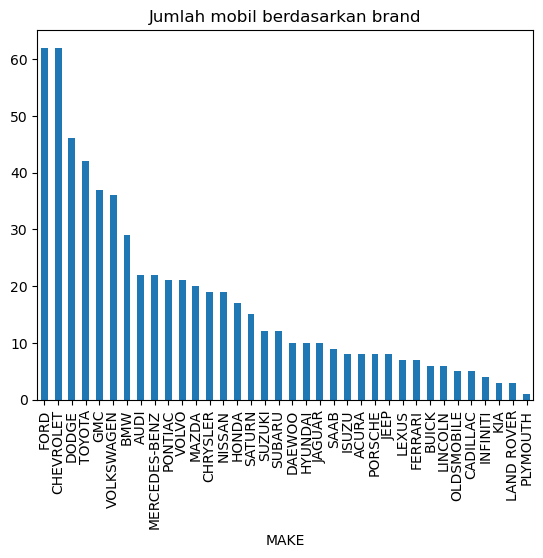

In [23]:
# bar plot jumlah mobil per pabrikan
data['MAKE'].value_counts().plot.bar()
plt.title('Jumlah mobil berdasarkan brand')
plt.show()

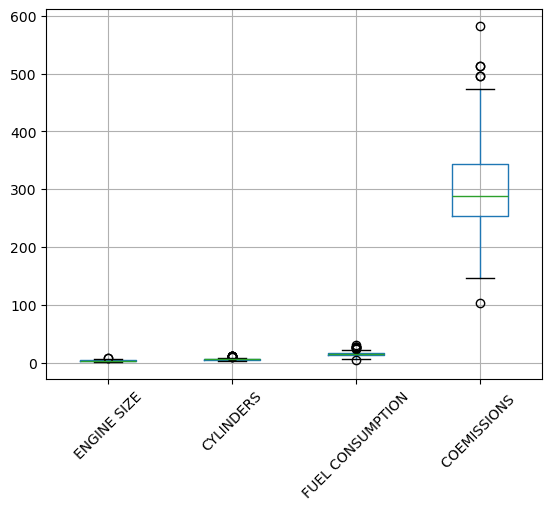

In [24]:
# boxplot
data.boxplot()
plt.xticks(rotation =45)
plt.show()

<Axes: >

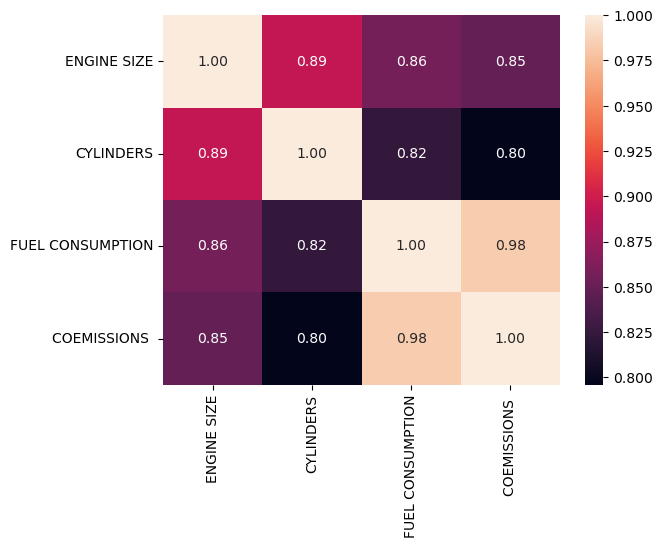

In [25]:
# heatmap kolerasi
numeric_cols= data.select_dtypes(include=['number'])
corr_mat=numeric_cols.corr()
sns.heatmap(corr_mat,annot=True, fmt='.2f')

## Data Transformation

In [27]:
# import library
from sklearn.preprocessing import LabelEncoder

# Features selection
features = ['ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'VEHICLE CLASS', 'COEMISSIONS ']
X = data[features].copy()

# Target variable
y = data['FUEL CONSUMPTION']

print("Features & Target Selected:")
print(f"Features: {list(X.columns)}")
print(f"Target: {y.name}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Encode categorical features
label_encoders = {}
for col in ['TRANSMISSION', 'FUEL', 'VEHICLE CLASS']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Data Transformation Selesai:")
print(f"X shape setelah encoding: {X.shape}")
print(f"Tipe data X: {X.dtypes}")

Features & Target Selected:
Features: ['ENGINE SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'VEHICLE CLASS', 'COEMISSIONS ']
Target: FUEL CONSUMPTION
X shape: (632, 6), y shape: (632,)
Data Transformation Selesai:
X shape setelah encoding: (632, 6)
Tipe data X: ENGINE SIZE      float64
CYLINDERS          int64
TRANSMISSION       int64
FUEL               int64
VEHICLE CLASS      int64
COEMISSIONS        int64
dtype: object


## Model Preparation

In [31]:
# import library
from sklearn.model_selection import train_test_split

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain-Test Split (80%-20%):")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")



Train-Test Split (80%-20%):
Training set: 505 samples
Test set: 127 samples
X_train shape: (505, 6), X_test shape: (127, 6)
y_train shape: (505,), y_test shape: (127,)


## Training

In [32]:
# import linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi fuel consumption (L/100km)
y_pred_consumption = model.predict(X_test)

# Konversi prediksi dan actual ke km/L
y_pred_efficiency = 100 / y_pred_consumption
y_actual_efficiency = 100 / y_test

print("\nHASIL KONVERSI KE km/L:")
print("Contoh beberapa prediksi:")
for i in range(3):
    print(f"  Actual: {y_actual_efficiency.iloc[i]:.2f} km/L, Predicted: {y_pred_efficiency[i]:.2f} km/L")


HASIL KONVERSI KE km/L:
Contoh beberapa prediksi:
  Actual: 8.33 km/L, Predicted: 8.13 km/L
  Actual: 5.41 km/L, Predicted: 5.29 km/L
  Actual: 6.37 km/L, Predicted: 6.15 km/L


## Evaluasi Kinerja Model

In [37]:
# import
from sklearn.metrics import mean_squared_error, r2_score

# evaluasi model
mse = mean_squared_error(y_actual_efficiency, y_pred_efficiency)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_actual_efficiency - y_pred_efficiency))
r2 = r2_score(y_actual_efficiency, y_pred_efficiency)

print(f"\nMODEL PERFORMANCE (dalam km/L):")
print(f"R² Score: {r2:.4f}") # akurasi
print(f"MSE: {mse:.4f} km/L") # rata-rata kuadrat error
print(f"RMSE: {rmse:.4f} km/L") # rata-rata error prediksi
print(f"MAE: {mae:.4f} km/L") # rata-rata error absolut, hanya meleset


MODEL PERFORMANCE (dalam km/L):
R² Score: 0.9590
MSE: 0.1442 km/L
RMSE: 0.3797 km/L
MAE: 0.1851 km/L


In [40]:
# Buat contoh data baru
example_vehicle = {
    'ENGINE SIZE': 2.0,
    'CYLINDERS': 4,
    'TRANSMISSION': 'M5',  # Manual 5-speed
    'FUEL': 'X',          # Regular gasoline
    'VEHICLE CLASS': 'COMPACT',
    'COEMISSIONS ': 200
}

# Convert ke format yang sesuai dengan model
example_df = pd.DataFrame([example_vehicle])
for col in ['TRANSMISSION', 'FUEL', 'VEHICLE CLASS']:
    example_df[col] = label_encoders[col].transform(example_df[col])

# Prediksi
predicted_consumption = model.predict(example_df)[0]
predicted_efficiency = 100 / predicted_consumption

print(f"Kendaraan contoh:")
print(f"  Engine: {example_vehicle['ENGINE SIZE']}L, {example_vehicle['CYLINDERS']} cylinders")
print(f"  Transmission: {example_vehicle['TRANSMISSION']}, Fuel: {example_vehicle['FUEL']}")
print(f"  Predicted Fuel Consumption: {predicted_consumption:.2f} L/100km")
print(f"  Predicted Fuel Efficiency: {predicted_efficiency:.2f} km/L")

Kendaraan contoh:
  Engine: 2.0L, 4 cylinders
  Transmission: M5, Fuel: X
  Predicted Fuel Consumption: 10.06 L/100km
  Predicted Fuel Efficiency: 9.94 km/L


In [42]:
# Buat contoh data baru 2
example_vehicle = {
    'ENGINE SIZE': 2.8,
    'CYLINDERS': 4,
    'TRANSMISSION': 'AS6',  # Automatic 6-speed
    'FUEL': 'D',          # Diesel
    'VEHICLE CLASS': 'SUV',
    'COEMISSIONS ': 300
}

# Convert ke format yang sesuai dengan model
example_df = pd.DataFrame([example_vehicle])
for col in ['TRANSMISSION', 'FUEL', 'VEHICLE CLASS']:
    example_df[col] = label_encoders[col].transform(example_df[col])

# Prediksi
predicted_consumption = model.predict(example_df)[0]
predicted_efficiency = 100 / predicted_consumption

print(f"Kendaraan contoh:")
print(f"  Engine: {example_vehicle['ENGINE SIZE']}L, {example_vehicle['CYLINDERS']} cylinders")
print(f"  Transmission: {example_vehicle['TRANSMISSION']}, Fuel: {example_vehicle['FUEL']}")
print(f"  Predicted Fuel Consumption: {predicted_consumption:.2f} L/100km")
print(f"  Predicted Fuel Efficiency: {predicted_efficiency:.2f} km/L")

Kendaraan contoh:
  Engine: 2.8L, 4 cylinders
  Transmission: AS6, Fuel: D
  Predicted Fuel Consumption: 14.09 L/100km
  Predicted Fuel Efficiency: 7.10 km/L


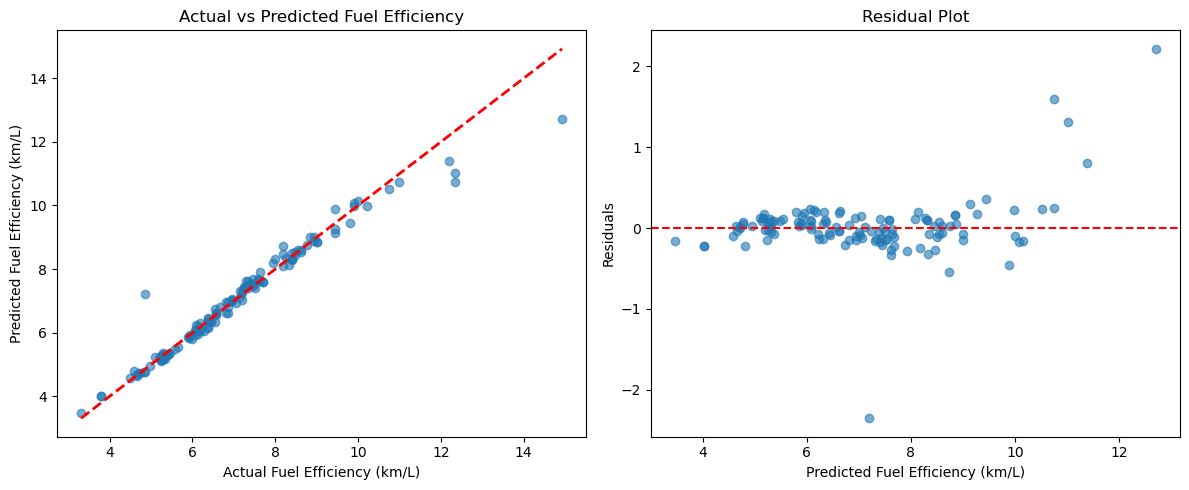

In [43]:
# plot
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted Fuel Efficiency
plt.subplot(1, 2, 1)
plt.scatter(y_actual_efficiency, y_pred_efficiency, alpha=0.6)
plt.plot([y_actual_efficiency.min(), y_actual_efficiency.max()], 
         [y_actual_efficiency.min(), y_actual_efficiency.max()], 'r--', lw=2)
plt.xlabel('Actual Fuel Efficiency (km/L)')
plt.ylabel('Predicted Fuel Efficiency (km/L)')
plt.title('Actual vs Predicted Fuel Efficiency')

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_actual_efficiency - y_pred_efficiency
plt.scatter(y_pred_efficiency, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Fuel Efficiency (km/L)')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

## Diskusi

Berdasarkan metrik evaluasi yang diperoleh, model regresi linear menunjukkan performa yang sangat baik dalam memprediksi efisiensi bahan bakar kendaraan. Nilai R² sebesar 0,9590 mengindikasikan bahwa model ini mampu menjelaskan 95,9% variasi dalam efisiensi bahan bakar, sementara hanya 4,1% variasi yang tidak dapat dijelaskan oleh fitur-fitur yang digunakan. Tingkat R² yang mendekati 1.0 ini menunjukkan bahwa model sangat sesuai dengan data.

Didukung oleh nilai error yang rendah, yaitu RMSE sebesar 0,3797 km/L dan MAE sebesar 0,1851 km/L, model ini memiliki tingkat presisi yang sangat baik untuk aplikasi praktis. Dengan error rata-rata di bawah ±0,4 km/L, prediksi yang dihasilkan cukup akurat untuk mendukung pengambilan keputusan. Konsistensi antara nilai R² yang tinggi dan error metrics yang rendah mengkonfirmasi bahwa model tidak hanya menjelaskan variasi data dengan baik, tetapi juga menghasilkan prediksi yang reliable.

#### Interpretasi Faktor yang Mempengaruhi Efisiensi Bahan Bakar

Analisis koefisien regresi mengungkapkan bahwa ukuran mesin (engine size) merupakan faktor paling dominan yang mempengaruhi efisiensi bahan bakar. Setiap peningkatan dalam kapasitas mesin secara signifikan meningkatkan konsumsi bahan bakar. Faktor kedua terpenting adalah jumlah silinder, di mana konfigurasi mesin dengan lebih banyak silinder cenderung lebih boros bahan bakar.

Kelas kendaraan juga memberikan pengaruh cukup besar, dengan kendaraan berat seperti SUV menunjukkan efisiensi yang lebih rendah dibandingkan kendaraan compact dan subcompact. Jenis transmisi dan tipe bahan bakar memberikan pengaruh yang berarti tetapi tidak sebesar ukuran mesin dan jumlah silinder. Namun, tetap relevan dalam optimasi efisiensi keseluruhan.

Sebagai catatan khusus, variabel CO2 emissions juga menunjukkan pengaruh yang signifikan dalam model. Namun, tingginya pengaruh ini disebabkan oleh hubungan antara CO2 emissions dan fuel consumption di mana CO2 emissions secara langsung dihitung dari konsumsi bahan bakar berdasarkan faktor emisi yang tetap. Oleh karena itu, meskipun CO2 emissions meningkatkan akurasi prediktif model, interpretasi engineering yang bermakna lebih difokuskan pada parameter desain murni seperti engine size, cylinders, dan vehicle class, yang dapat secara langsung dimanipulasi dalam proses perancangan kendaraan.

In [2]:
pip freeze > requirements_linear.txt

Note: you may need to restart the kernel to use updated packages.
